## DATASET UNDERSTANDING & DATA PREPROCESSING

1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. LOAD DATASET

In [4]:
df = pd.read_csv("Mall_Customers.csv")

3. BASIC EXPLORATION

In [5]:
df.shape

(200, 5)

Observation:
The dataset contains 200 rows and 5 columns.

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

The dataset contains CustomerID, Gender, Age, Annual Income and Spending Score columns.

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


The first five records are displayed successfully.

In [8]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


The last five records are displayed successfully.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


The summary statistics show the distribution of numerical features such as age, annual income and spending score.

4. MISSING VALUES

In [11]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

No missing values are present in the dataset.

5. DUPLICATE VALUES

In [16]:
df.duplicated().sum()


np.int64(0)

No duplicate records were found.


6. DATA TYPES

In [17]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


The dataset contains one categorical column (Gender) and four numerical columns.

7. OUTLIER DETECTION



    Boxplots

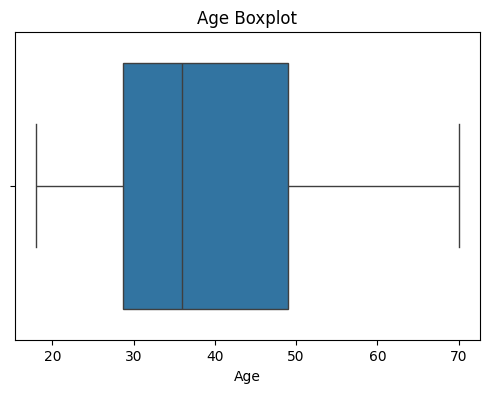

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

Very few outliers are observed in the Age column.

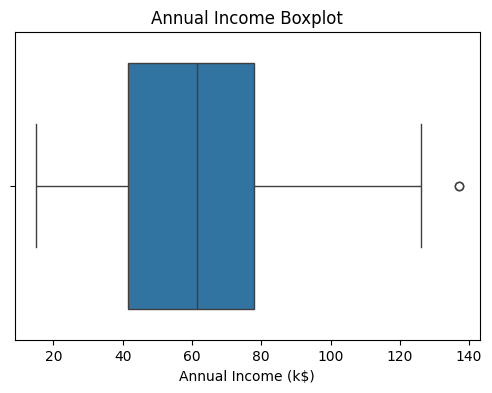

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Annual Income (k$)"])
plt.title("Annual Income Boxplot")
plt.show()

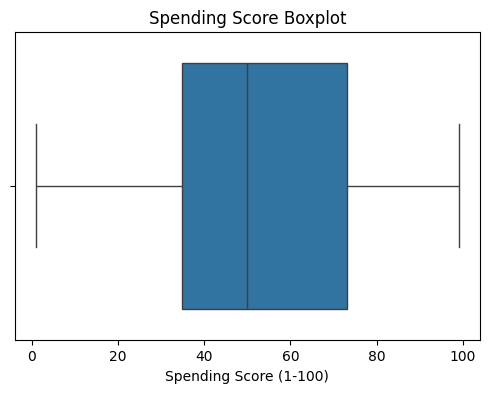

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Spending Score (1-100)"])
plt.title("Spending Score Boxplot")
plt.show()

IQR method

In [21]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

print(outliers)

Empty DataFrame
Columns: [CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)]
Index: []


No significant outliers were detected using the IQR method.

FINAL CLEAN DATASET

In [23]:
df.to_csv("Mall_Customers_Clean.csv", index=False)